<a href="https://colab.research.google.com/github/mudassir7328/House-Price-Prediction/blob/main/house_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("house.csv")

print("Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Shape: (20640, 10)

First 5 Rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [4]:
print("\nData Info:")
print(df.info())



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [6]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].mean())

print("\nAfter Filling - Missing Values:")
print(df.isnull().sum())


After Filling - Missing Values:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [7]:
le = LabelEncoder()
df["ocean_proximity"] = le.fit_transform(df["ocean_proximity"])

print("\nEncoded ocean_proximity classes:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} --> {i}")


Encoded ocean_proximity classes:
  <1H OCEAN --> 0
  INLAND --> 1
  ISLAND --> 2
  NEAR BAY --> 3
  NEAR OCEAN --> 4


In [8]:
X = df.drop(columns=["median_house_value"])
y = df["median_house_value"]

print("\nFeatures (X):")
print(X.columns.tolist())
print("\nTarget (y):", y.name)



Features (X):
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']

Target (y): median_house_value


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"\nTraining Size : {X_train.shape}")
print(f"Testing  Size : {X_test.shape}")


Training Size : (16512, 9)
Testing  Size : (4128, 9)


In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("\nScaling Done!")


Scaling Done!


In [11]:
model = LinearRegression()

model.fit(X_train, y_train)
print("\nModel Training Complete!")


Model Training Complete!


In [12]:
y_pred = model.predict(X_test)

print("\nSample Predictions (first 10):")
print(y_pred[:10])



Sample Predictions (first 10):
[ 75616.18733782 166419.13655163 264751.07303087 275770.17606472
 278280.66805524 167145.92371401 299347.46637949 235952.52446911
 268602.43686858 416502.74335388]


In [13]:
comparison = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": np.round(y_pred[:10], 2)
})
print("\nActual vs Predicted (first 10 rows):")
print(comparison.to_string(index=False))



Actual vs Predicted (first 10 rows):
  Actual  Predicted
 47700.0   75616.19
 45800.0  166419.14
500001.0  264751.07
218600.0  275770.18
278000.0  278280.67
158700.0  167145.92
198200.0  299347.47
157500.0  235952.52
340000.0  268602.44
446600.0  416502.74


In [14]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("         MODEL PERFORMANCE STATS        ")
print("Mean Absolute Error (MAE) :",round(mae,2))
print("Mean Squared Error (MSE) :",round(mse,2))
print("Root Mean Squared Error (RMSE) :",round(rmse,2))
print("R^2 Score (Model Accuracy) : ",round(r2,3))

         MODEL PERFORMANCE STATS        
Mean Absolute Error (MAE) : 51846.88
Mean Squared Error (MSE) : 5055025116.17
Root Mean Squared Error (RMSE) : 71098.7
R^2 Score (Model Accuracy) :  0.614


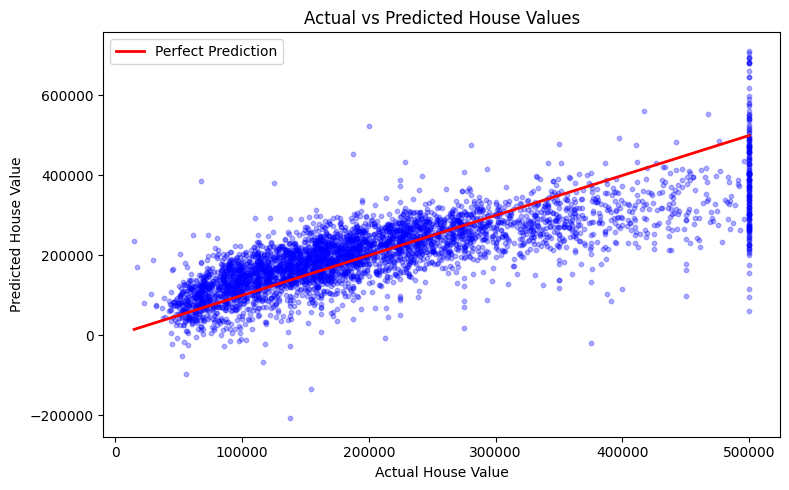

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color="blue", s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
print("\nPredict New House Price")

longitude          = float(input("Enter Longitude              : "))
latitude           = float(input("Enter Latitude               : "))
housing_median_age = float(input("Enter Housing Median Age     : "))
total_rooms        = float(input("Enter Total Rooms            : "))
total_bedrooms     = float(input("Enter Total Bedrooms         : "))
population         = float(input("Enter Population             : "))
households         = float(input("Enter Households             : "))
median_income      = float(input("Enter Median Income          : "))
ocean_proximity    = float(input("Enter Ocean Proximity (0-4)  : "))

new_input = scaler.transform([[longitude, latitude, housing_median_age,
                                total_rooms, total_bedrooms, population,
                                households, median_income, ocean_proximity]])

predicted_price = model.predict(new_input)

print(f"  Predicted House Price : {round(predicted_price[0],2)}")


Predict New House Price
Enter Longitude              : -122
Enter Latitude               : 34.88
Enter Housing Median Age     : 41
Enter Total Rooms            : 880
Enter Total Bedrooms         : 229
Enter Population             : 2402
Enter Households             : 219
Enter Median Income          : 7.72782
Enter Ocean Proximity (0-4)  : 2
  Predicted House Price : 441113.27


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
